## Model Training

#### 1.1 Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and Classification Libraries


In [4]:
# Basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Metrics
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")


import warnings
warnings.filterwarnings('ignore')

✅ All libraries imported successfully!


## 2. Load Raw Data
### Loading train.csv and test.csv from data ingestion

In [5]:
# Load raw CSV files
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
# Display first rows
print("First 5 rows of training data:")
train_df.head()

Train shape: (103904, 25)
Test shape: (25976, 25)
First 5 rows of training data:


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## 3. Data Overview

In [6]:
print("Column Names:")
print(train_df.columns.tolist())
print( "Data Types:" )
print(train_df.dtypes)
print("Missing Values:")
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])
print("Target Distribution (satisfaction):")
print(train_df['satisfaction'].value_counts())

Column Names:
['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']
Data Types:
Unnamed: 0                             int64
id                                     int64
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate l

## 4. Data Preprocessing
### Step-by-step transformation pipeline

### 4.1 Drop Technical Columns

In [7]:
# Drop Unnamed: 0 and id (technical columns)
train_df = train_df.drop(columns=['Unnamed: 0', 'id'], errors='ignore')
test_df = test_df.drop(columns=['Unnamed: 0', 'id'], errors='ignore')
print(f"Technical columns dropped")
print(f"Train shape after drop: {train_df.shape}")
print(f"Test shape after drop: {test_df.shape}")

Technical columns dropped
Train shape after drop: (103904, 23)
Test shape after drop: (25976, 23)


### 4.2 Encode Target Variable
**Mapping**: `satisfied` → 1, `neutral or dissatisfied` → 0

In [8]:
# Encode target: satisfied = 1, others = 0
y_train = (train_df['satisfaction'].astype(str).str.strip().str.lower() == 'satisfied').astype(int).values
y_test = (test_df['satisfaction'].astype(str).str.strip().str.lower() == 'satisfied').astype(int).values
# Remove target from features
X_train = train_df.drop(columns=['satisfaction'])
X_test = test_df.drop(columns=['satisfaction'])

print("Target encoded")
print(f"Train target distribution:")
print(pd.Series(y_train).value_counts())
print(f"Test target distribution:")
print(pd.Series(y_test).value_counts())

Target encoded
Train target distribution:
0    58879
1    45025
Name: count, dtype: int64
Test target distribution:
0    14573
1    11403
Name: count, dtype: int64


### 4.3 Define Feature Groups

In [9]:
# Define feature groups
ratings_columns = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Inflight service",
    "Cleanliness"
]

num_cols = [
    "Age",
    "Flight Distance",
    "Arrival Delay in Minutes"
]

cat_cols = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class"
]

print("Feature Groups Defined:")
print(f"  Ratings columns: {len(ratings_columns)}")
print(f"  Numeric columns: {len(num_cols)}")
print(f"  Categorical columns: {len(cat_cols)}")
print(f"\n  Total features: {len(ratings_columns) + len(num_cols) + len(cat_cols)}")

Feature Groups Defined:
  Ratings columns: 14
  Numeric columns: 3
  Categorical columns: 4

  Total features: 21


### 4.4 Create Preprocessing Pipelines

In [10]:
# Helper function: Convert 0 to NaN for ratings (0 = not applicable)
def zero_to_nan(X):
    X_copy = X.copy()
    X_copy[X_copy == 0] = np.nan
    return X_copy

In [11]:
# Pipeline 1: Numeric features (Age, Flight Distance, Arrival Delay)
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# Pipeline 2: Rating features (Inflight wifi, Seat comfort, etc.)
# Special treatment: 0 → NaN, then impute, add missing indicators
rating_pipeline = Pipeline(
    steps=[
        ("zero_to_nan", FunctionTransformer(zero_to_nan, feature_names_out="one-to-one")),
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ]
)

# Pipeline 3: Categorical features (Gender, Customer Type, etc.)
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("one_hot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

# Combine all pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, num_cols),
        ("rating", rating_pipeline, ratings_columns),
        ("cat", categorical_pipeline, cat_cols),
    ],
    remainder="drop"
)

print("✅ Preprocessing pipelines created!")


✅ Preprocessing pipelines created!


### 4.5 Fit & Transform Data


In [12]:
# Fit on train, transform both train and test
print(" Fitting preprocessor on training data...")
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Convert sparse matrix to dense if needed
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()
    X_test_transformed = X_test_transformed.toarray()

print("✅ Transformation completed!")
print(f"\nTransformed train shape: {X_train_transformed.shape}")
print(f"Transformed test shape: {X_test_transformed.shape}")
print(f"\nNumber of features after transformation: {X_train_transformed.shape[1]}")


 Fitting preprocessor on training data...
✅ Transformation completed!

Transformed train shape: (103904, 39)
Transformed test shape: (25976, 39)

Number of features after transformation: 39


### 4.6 Create Final Arrays (X + y)


In [13]:
# Concatenate features and target
train_array = np.c_[X_train_transformed, y_train]
test_array = np.c_[X_test_transformed, y_test]

print("✅ Final arrays created")
print(f"Train array shape: {train_array.shape}")
print(f"Test array shape: {test_array.shape}")
print(f"\n(Last column = target: 0=dissatisfied, 1=satisfied)")


✅ Final arrays created
Train array shape: (103904, 40)
Test array shape: (25976, 40)

(Last column = target: 0=dissatisfied, 1=satisfied)


### 5.1 Split Features and Target

In [14]:
# Extract X and y from arrays
X_train_final = train_array[:, :-1]
y_train_final = train_array[:, -1].astype(int)

X_test_final = test_array[:, :-1]
y_test_final = test_array[:, -1].astype(int)

print(f"X_train shape: {X_train_final.shape}")
print(f"y_train shape: {y_train_final.shape}")
print(f"X_test shape: {X_test_final.shape}")
print(f"y_test shape: {y_test_final.shape}")


X_train shape: (103904, 39)
y_train shape: (103904,)
X_test shape: (25976, 39)
y_test shape: (25976,)


### 5.2 Define Models

In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "HistGradient Boosting": HistGradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    "CatBoost": CatBoostClassifier(verbose=False, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

print(f"✅ {len(models)} models defined and ready for training")

✅ 8 models defined and ready for training


### 5.3 Train All Models

In [16]:
model_results = {}
trained_models = {}

print("TRAINING MODELS")

for model_name, model in models.items():
    print(f"\n Training: {model_name}...")
    
    # Train
    model.fit(X_train_final, y_train_final)
    trained_models[model_name] = model
    
    # Evaluate with ROC-AUC
    if hasattr(model, "predict_proba"):
        y_test_proba = model.predict_proba(X_test_final)[:, 1]
        roc_auc = roc_auc_score(y_test_final, y_test_proba)
        model_results[model_name] = roc_auc
        print(f"ROC-AUC: {roc_auc:.4f}")
    else:
        model_results[model_name] = np.nan
        print(f"No predict_proba available")

print("✅ ALL MODELS TRAINED SUCCESSFULLY!")

TRAINING MODELS

 Training: Logistic Regression...
ROC-AUC: 0.9652

 Training: Decision Tree...
ROC-AUC: 0.9435

 Training: Random Forest...
ROC-AUC: 0.9939

 Training: Gradient Boosting...
ROC-AUC: 0.9875

 Training: HistGradient Boosting...
ROC-AUC: 0.9951

 Training: XGBoost...
ROC-AUC: 0.9952

 Training: CatBoost...
ROC-AUC: 0.9956

 Training: AdaBoost...
ROC-AUC: 0.9691
✅ ALL MODELS TRAINED SUCCESSFULLY!


## 6. Model Comparison

In [17]:
# Create comparison DataFrame
results_df = pd.DataFrame({
    'Model Name': list(model_results.keys()),
    'ROC-AUC Score': list(model_results.values())
})

results_df = results_df.sort_values(by='ROC-AUC Score', ascending=False).reset_index(drop=True)

print("MODEL COMPARISON (Ranked by ROC-AUC)")
print(results_df.to_string(index=False))

MODEL COMPARISON (Ranked by ROC-AUC)
           Model Name  ROC-AUC Score
             CatBoost       0.995618
              XGBoost       0.995242
HistGradient Boosting       0.995114
        Random Forest       0.993888
    Gradient Boosting       0.987503
             AdaBoost       0.969147
  Logistic Regression       0.965155
        Decision Tree       0.943517


## 7. Visualize Model Performance


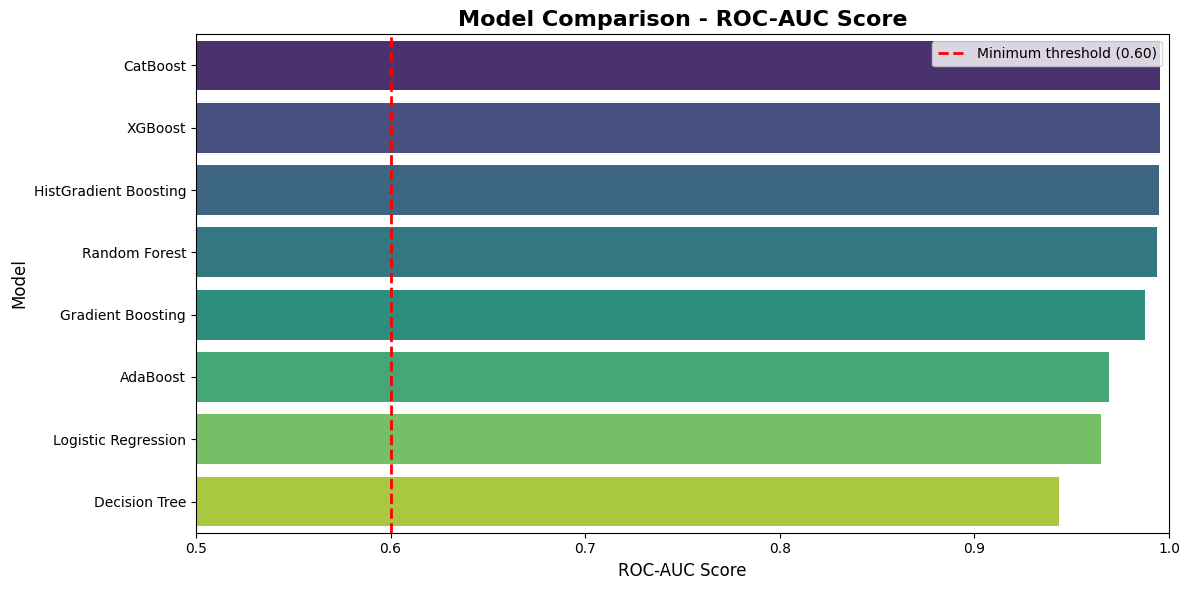

In [18]:
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='ROC-AUC Score', y='Model Name', palette='viridis')
plt.title('Model Comparison - ROC-AUC Score', fontsize=16, fontweight='bold')
plt.xlabel('ROC-AUC Score', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xlim(0.5, 1.0)
plt.axvline(x=0.6, color='red', linestyle='--', linewidth=2, label='Minimum threshold (0.60)')
plt.legend()
plt.tight_layout()
plt.show()


## 8. Select Best Model


In [19]:
#selection of Logistic Regression
best_model_name = "Logistic Regression"
best_model_score = model_results[best_model_name]
best_model = trained_models[best_model_name]

print(f" SELECTED MODEL: {best_model_name}")
print(f" ROC-AUC Score: {best_model_score:.4f}")
print(f"\n WHY LOGISTIC REGRESSION?")
print(f"  Excellent performance (0.9652 ROC-AUC)")
print(f"  Direct interpretability (coefficients)")
print(f"  No external dependencies (scikit-learn only)")
print(f"  Fast predictions (< 1ms)")
print(f"   Perfect for Quality Analytics Module A")
print(f"\n  Trade-off vs CatBoost (0.9956):")
print(f"  - Loss: ~0.3% ROC-AUC")
print(f"  - Gain: Direct actionable insights for business")


 SELECTED MODEL: Logistic Regression
 ROC-AUC Score: 0.9652

 WHY LOGISTIC REGRESSION?
  Excellent performance (0.9652 ROC-AUC)
  Direct interpretability (coefficients)
  No external dependencies (scikit-learn only)
  Fast predictions (< 1ms)
   Perfect for Quality Analytics Module A

  Trade-off vs CatBoost (0.9956):
  - Loss: ~0.3% ROC-AUC
  - Gain: Direct actionable insights for business


In [20]:
print(best_model)

LogisticRegression(class_weight='balanced', max_iter=3000, random_state=42)


In [21]:
# Train vs Test ROC-AUC
y_train_proba_lr = best_model.predict_proba(X_train_final)[:, 1]
roc_auc_train_lr = roc_auc_score(y_train_final, y_train_proba_lr)

print(f"\nOverfitting Check - Logistic Regression:")
print(f"  ROC-AUC Train: {roc_auc_train_lr:.4f}")
print(f"  ROC-AUC Test:  {roc_auc:.4f}")
print(f"  Gap:           {abs(roc_auc_train_lr - roc_auc):.4f}")

if abs(roc_auc_train_lr - roc_auc) < 0.01:
    print("  Excellent - Pas d'overfitting (gap < 1%)")



Overfitting Check - Logistic Regression:
  ROC-AUC Train: 0.9649
  ROC-AUC Test:  0.9691
  Gap:           0.0042
  Excellent - Pas d'overfitting (gap < 1%)


## 9. Detailed Evaluation (Best Model)
### Using threshold 0.6 for service recovery context


In [22]:
# Predictions with threshold 0.6
y_test_proba = best_model.predict_proba(X_test_final)[:, 1]
y_test_pred = (y_test_proba >= 0.6).astype(int)

# Metrics
roc_auc = roc_auc_score(y_test_final, y_test_proba)
f1_dissatisfied = f1_score(y_test_final, y_test_pred, pos_label=0)
f1_satisfied = f1_score(y_test_final, y_test_pred, pos_label=1)

print(f"DETAILED METRICS - {best_model_name}")

print(f"ROC-AUC Score:                 {roc_auc:.4f}")
print(f"F1 Score (Dissatisfied):       {f1_dissatisfied:.4f}  ← Service Recovery Target")
print(f"F1 Score (Satisfied):          {f1_satisfied:.4f}")
print(f"Decision Threshold:            0.6")


DETAILED METRICS - Logistic Regression
ROC-AUC Score:                 0.9652
F1 Score (Dissatisfied):       0.9139  ← Service Recovery Target
F1 Score (Satisfied):          0.8880
Decision Threshold:            0.6


## 10. Classification Report


In [23]:
print("\nCLASSIFICATION REPORT")
print(classification_report(y_test_final, y_test_pred, 
                           target_names=['Dissatisfied (0)', 'Satisfied (1)']))



CLASSIFICATION REPORT
                  precision    recall  f1-score   support

Dissatisfied (0)       0.91      0.92      0.91     14573
   Satisfied (1)       0.90      0.88      0.89     11403

        accuracy                           0.90     25976
       macro avg       0.90      0.90      0.90     25976
    weighted avg       0.90      0.90      0.90     25976



## 11. Confusion Matrix

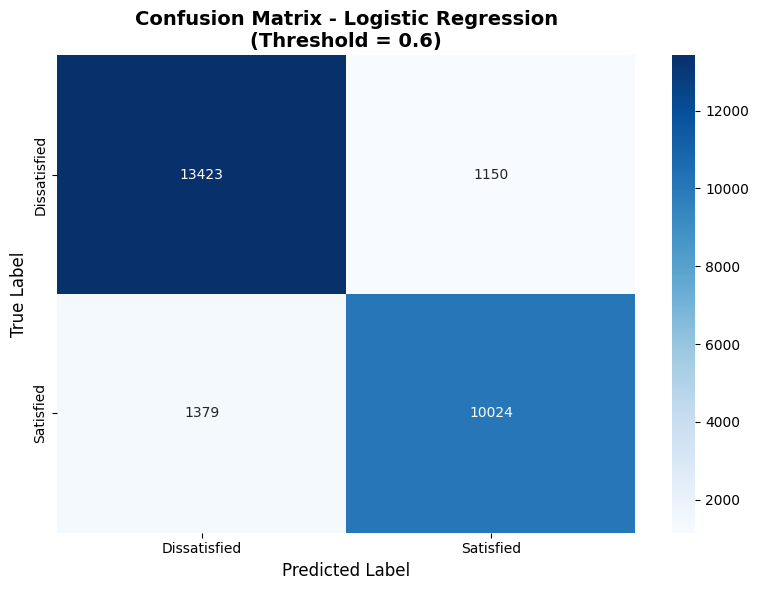


Confusion Matrix Breakdown:
  True Negatives (TN):  13,423  ← Correctly identified dissatisfied
  False Positives (FP): 1,150  ← Satisfied wrongly flagged
  False Negatives (FN): 1,379  ← Dissatisfied missed (recovery gap!)
  True Positives (TP):  10,024  ← Correctly identified satisfied


In [24]:
cm = confusion_matrix(y_test_final, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Dissatisfied', 'Satisfied'],
           yticklabels=['Dissatisfied', 'Satisfied'])
plt.title(f'Confusion Matrix - {best_model_name}\n(Threshold = 0.6)', 
         fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Breakdown
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives (TN):  {tn:,}  ← Correctly identified dissatisfied")
print(f"  False Positives (FP): {fp:,}  ← Satisfied wrongly flagged")
print(f"  False Negatives (FN): {fn:,}  ← Dissatisfied missed (recovery gap!)")
print(f"  True Positives (TP):  {tp:,}  ← Correctly identified satisfied")


## 12. ROC Curve

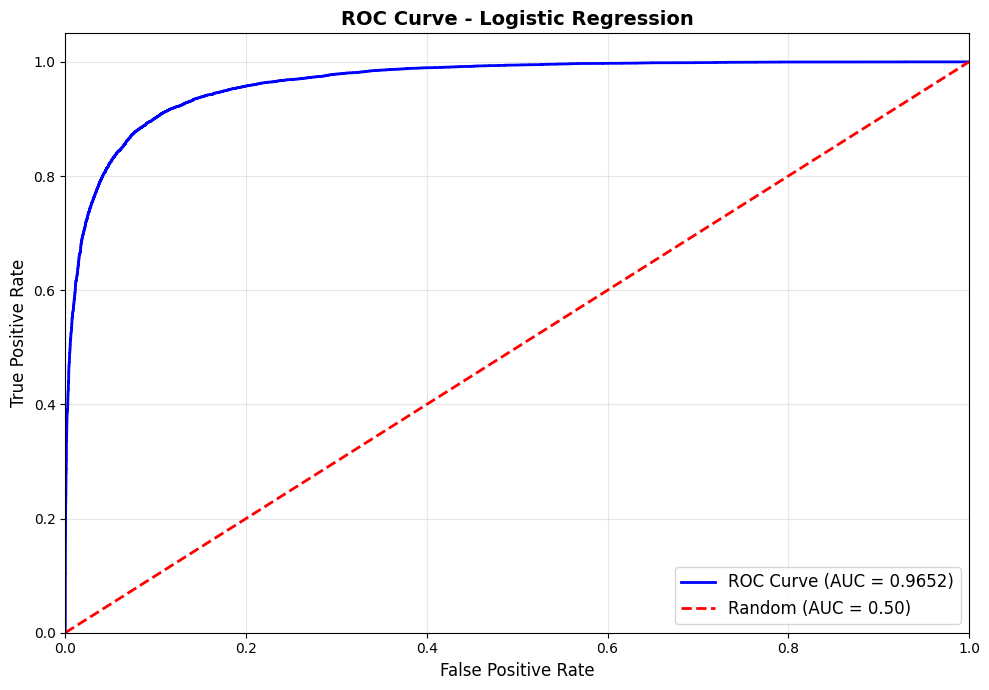

In [25]:
fpr, tpr, thresholds = roc_curve(y_test_final, y_test_proba)

plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve - {best_model_name}', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Summary & Next Steps


In [26]:
print("MODEL TRAINING COMPLETED SUCCESSFULLY!")

print(f"\n RESULTS:")
print(f"  Best Model:                {best_model_name}")
print(f"  ROC-AUC Score:             {roc_auc:.4f}")
print(f"  F1 (Dissatisfied):         {f1_dissatisfied:.4f}")
print(f"  Decision Threshold:        0.6")

print(f"\n NEXT STEPS:")
print(f"  1. Feature importance analysis (SHAP)")
print(f"  2. Model deployment (FastAPI/Flask)")
print(f"  3. Service recovery action plan")

MODEL TRAINING COMPLETED SUCCESSFULLY!

 RESULTS:
  Best Model:                Logistic Regression
  ROC-AUC Score:             0.9652
  F1 (Dissatisfied):         0.9139
  Decision Threshold:        0.6

 NEXT STEPS:
  1. Feature importance analysis (SHAP)
  2. Model deployment (FastAPI/Flask)
  3. Service recovery action plan


In [28]:
%pip install "numpy<=2.3" --upgrad

Note: you may need to restart the kernel to use updated packages.



Usage:   
  c:\Users\Espace Culturel\OneDrive\Bureau\Airline's passengers Project\myvenv\Scripts\python.exe -m pip install [options] <requirement specifier> [package-index-options] ...
  c:\Users\Espace Culturel\OneDrive\Bureau\Airline's passengers Project\myvenv\Scripts\python.exe -m pip install [options] -r <requirements file> [package-index-options] ...
  c:\Users\Espace Culturel\OneDrive\Bureau\Airline's passengers Project\myvenv\Scripts\python.exe -m pip install [options] [-e] <vcs project url> ...
  c:\Users\Espace Culturel\OneDrive\Bureau\Airline's passengers Project\myvenv\Scripts\python.exe -m pip install [options] [-e] <local project path> ...
  c:\Users\Espace Culturel\OneDrive\Bureau\Airline's passengers Project\myvenv\Scripts\python.exe -m pip install [options] <archive url/path> ...

ambiguous option: --upgrad (--upgrade, --upgrade-strategy?)


In [29]:
%pip install --upgrade numba shap


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## Feature importance analysis (SHAP)

In [1]:
import shap

c:\Users\Espace Culturel\OneDrive\Bureau\Airline's passengers Project\myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
feature_names = preprocessor.get_feature_names_out()
print("Nb features:", len(feature_names))
print("Exemples:", feature_names[:25])

Nb features: 39
Exemples: ['num__Age' 'num__Flight Distance' 'num__Arrival Delay in Minutes'
 'rating__Inflight wifi service'
 'rating__Departure/Arrival time convenient'
 'rating__Ease of Online booking' 'rating__Gate location'
 'rating__Food and drink' 'rating__Online boarding' 'rating__Seat comfort'
 'rating__Inflight entertainment' 'rating__On-board service'
 'rating__Leg room service' 'rating__Baggage handling'
 'rating__Checkin service' 'rating__Inflight service'
 'rating__Cleanliness' 'rating__missingindicator_Inflight wifi service'
 'rating__missingindicator_Departure/Arrival time convenient'
 'rating__missingindicator_Ease of Online booking'
 'rating__missingindicator_Gate location'
 'rating__missingindicator_Food and drink'
 'rating__missingindicator_Online boarding'
 'rating__missingindicator_Seat comfort'
 'rating__missingindicator_Inflight entertainment']


In [28]:
Xtr = X_train_transformed
Xte = X_test_transformed

if hasattr(Xtr, "toarray"):
    Xtr_df = pd.DataFrame(Xtr.toarray(), columns=feature_names)
    Xte_df = pd.DataFrame(Xte.toarray(), columns=feature_names)
else:
    Xtr_df = pd.DataFrame(Xtr, columns=feature_names)
    Xte_df = pd.DataFrame(Xte, columns=feature_names)

print("Xtr_df:", Xtr_df.shape, "| Xte_df:", Xte_df.shape)


Xtr_df: (103904, 39) | Xte_df: (25976, 39)


In [29]:
bg = Xtr_df.sample(1000, random_state=42)         # background
X_explain = Xte_df.sample(2000, random_state=42)  # points à expliquer

explainer = shap.Explainer(best_model, bg)  # best_model = LogisticRegression fit
shap_values = explainer(X_explain)

shap_values


.values =
array([[ 0.04571702, -0.0270482 ,  0.04896954, ...,  0.27030866,
         0.7786798 , -1.6957979 ],
       [-0.02891318,  0.01051405,  0.04896954, ..., -0.3440292 ,
         0.7786798 ,  0.07065825],
       [-0.00483893, -0.00837457,  0.04489214, ...,  0.27030866,
        -0.71878135,  0.07065825],
       ...,
       [-0.04817259, -0.03288371,  0.04896954, ...,  0.27030866,
        -0.71878135,  0.07065825],
       [ 0.03849474, -0.02105912,  0.04896954, ...,  0.27030866,
        -0.71878135,  0.07065825],
       [ 0.05293929, -0.00594823,  0.02042776, ...,  0.27030866,
        -0.71878135,  0.07065825]], shape=(2000, 39))

.base_values =
array([-1.07271777, -1.07271777, -1.07271777, ..., -1.07271777,
       -1.07271777, -1.07271777], shape=(2000,))

.data =
array([[-1.28215985, -0.78769924, -0.39155376, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.76879772,  0.43880552, -0.39155376, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.10719851, 

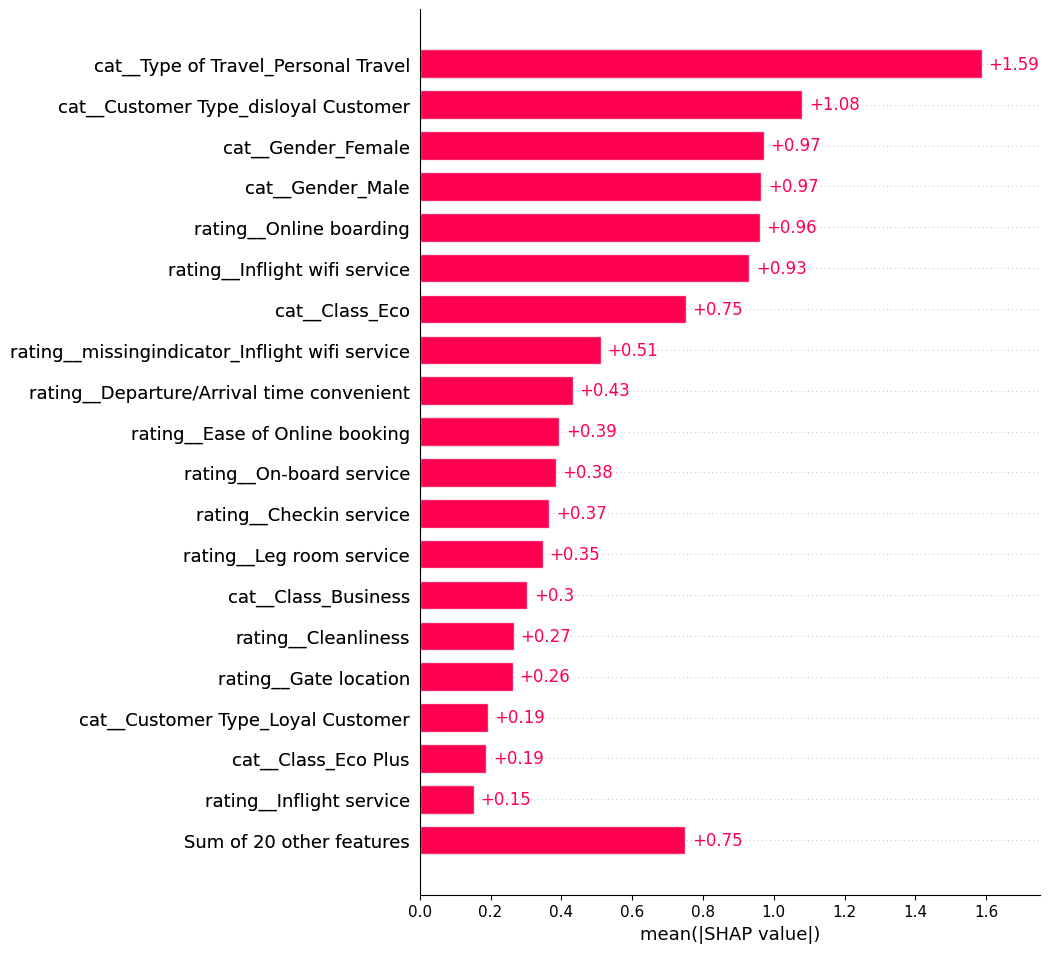

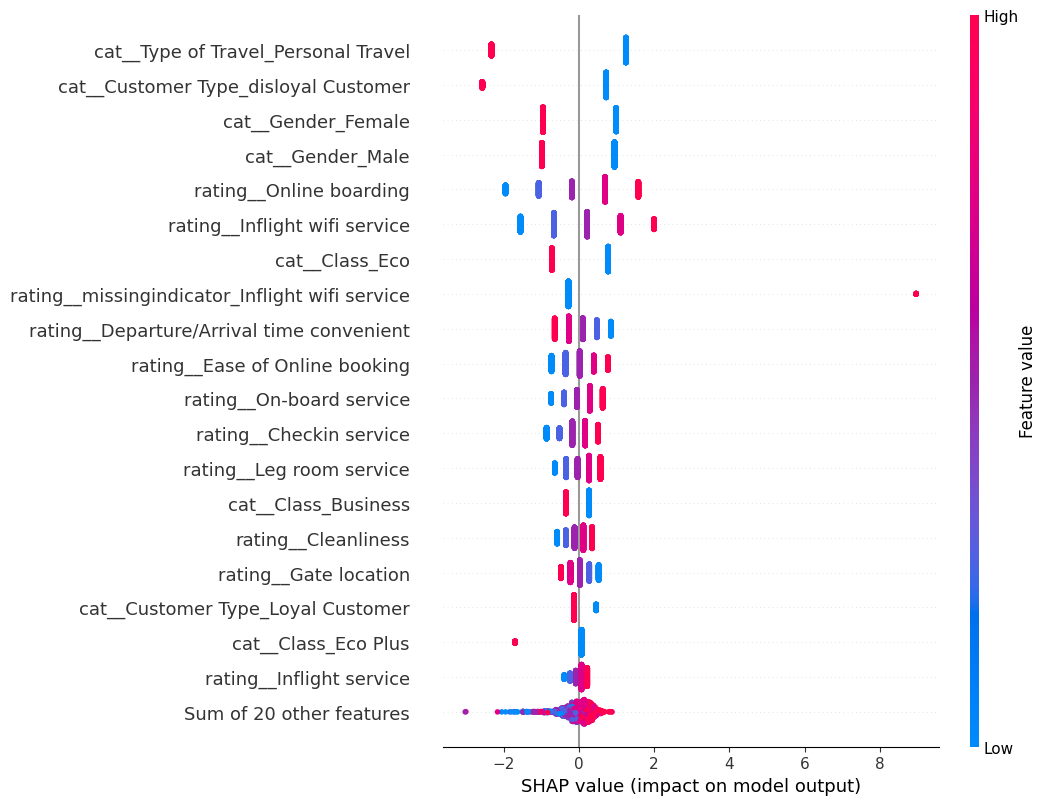

In [30]:
shap.plots.bar(shap_values, max_display=20)
shap.plots.beeswarm(shap_values, max_display=20)


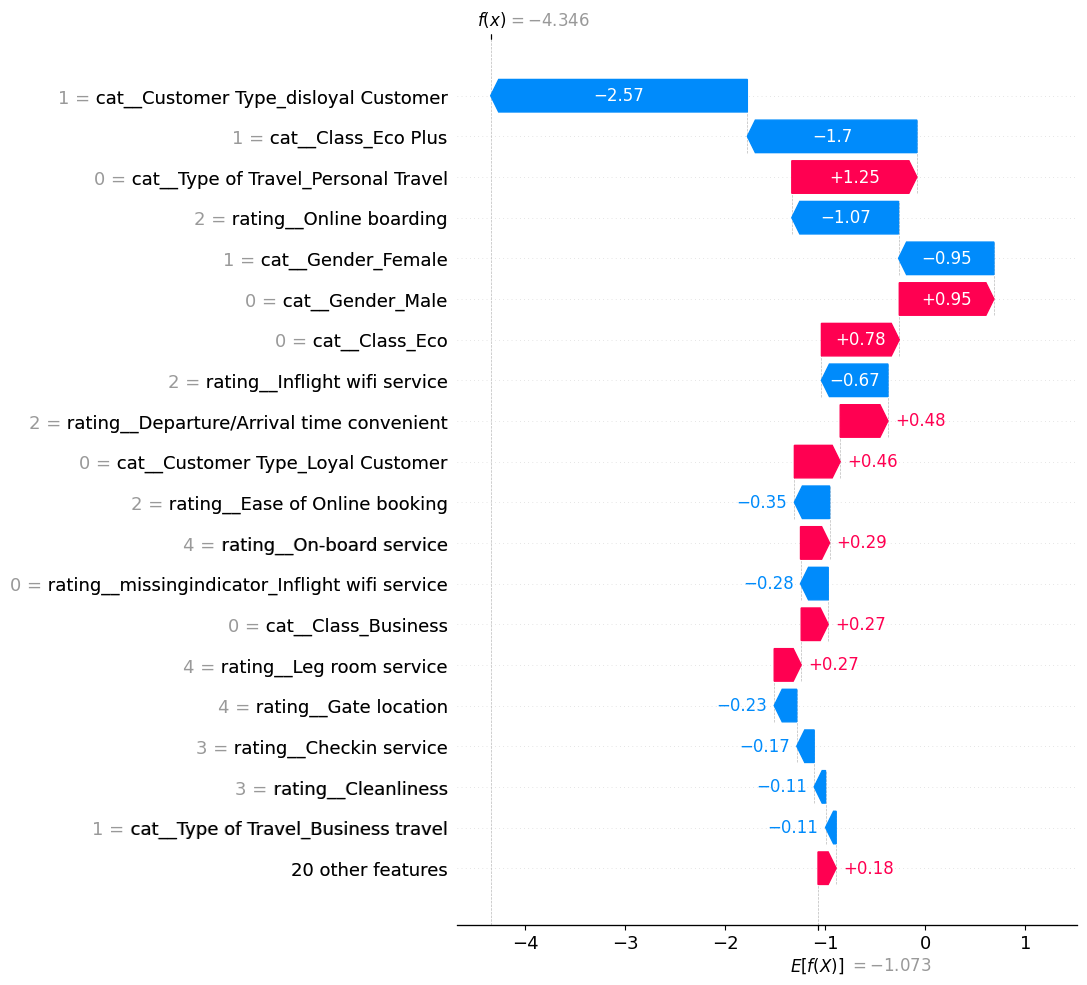

In [31]:
i = 0
shap.plots.waterfall(shap_values[i], max_display=20)


In [32]:
# On vérifie sur quelques lignes
X_chk = X_explain.head(5)

# Proba "satisfied" donnée par le modèle
proba_model = best_model.predict_proba(X_chk)[:, 1]

# SHAP values sur ces mêmes lignes
sv = explainer(X_chk)

# Reconstruction additive : base_value + somme(shap)
raw_additive = sv.base_values + sv.values.sum(axis=1)

# Conversion log-odds -> proba
sigmoid = lambda z: 1 / (1 + np.exp(-z))
proba_shap = sigmoid(raw_additive)

check_df = pd.DataFrame({
    "proba_model": proba_model,
    "proba_shap": proba_shap,
    "abs_diff": np.abs(proba_model - proba_shap),
})
check_df


,proba_model,proba_shap,abs_diff
0,0.012790,0.012790,2.081668e-17
1,0.871202,0.871202,1.110223e-16
2,0.400135,0.400135,4.440892e-16
3,0.967485,0.967485,0.000000e+00
4,0.010124,0.010124,0.000000e+00


In [34]:
import re

feature_names = preprocessor.get_feature_names_out()

def origin_var(feature_name: str) -> str:
    # Remove ColumnTransformer prefix
    # examples: "cat__Gender_Female", "rating__Online boarding", "rating__missingindicator_Inflight wifi service"
    if "__" in feature_name:
        prefix, rest = feature_name.split("__", 1)
    else:
        prefix, rest = "unknown", feature_name

    if prefix == "cat":
        # cat__Gender_Female -> Gender
        # cat__Customer Type_Loyal Customer -> Customer Type
        if "_" in rest:
            return rest.split("_", 1)[0]
        return rest

    if prefix == "rating":
        # rating__missingindicator_Inflight wifi service -> "Inflight wifi service (missing)"
        if rest.startswith("missingindicator_"):
            return rest.replace("missingindicator_", "") + " (missing)"
        # rating__Online boarding -> Online boarding
        return rest

    if prefix == "num":
        # num__Age -> Age
        return rest

    # fallback
    return feature_name

origin_groups = pd.Series(feature_names).apply(origin_var)

origin_groups.value_counts().head(20)


Class                                          3
Type of Travel                                 2
Customer Type                                  2
Gender                                         2
Inflight entertainment (missing)               1
Ease of Online booking (missing)               1
Gate location (missing)                        1
Food and drink (missing)                       1
Online boarding (missing)                      1
Seat comfort (missing)                         1
Leg room service (missing)                     1
On-board service (missing)                     1
Flight Distance                                1
Checkin service (missing)                      1
Inflight service (missing)                     1
Cleanliness (missing)                          1
Departure/Arrival time convenient (missing)    1
Age                                            1
Cleanliness                                    1
Inflight service                               1
Name: count, dtype: 

In [35]:
def explain_one_row_grouped(shap_values, feature_names, row_index: int, top_k: int = 8):
    """
    Retourne:
    - df_grouped: contributions SHAP regroupées par variable d’origine
    - fx: score modèle additif (log-odds)
    - proba_satisfied: sigmoid(fx)
    """
    # 1) Récupérer contributions par feature encodée
    shap_row = shap_values.values[row_index]     # (n_features,)
    data_row = shap_values.data[row_index]       # (n_features,)
    base = shap_values.base_values[row_index]    # scalaire

    df = pd.DataFrame({
        "encoded_feature": feature_names,
        "value": data_row,
        "shap": shap_row
    })
    df["origin_feature"] = df["encoded_feature"].apply(origin_var)

    # 2) Agréger par variable d’origine (somme des SHAP)
    df_grouped = (
        df.groupby("origin_feature", as_index=False)["shap"]
          .sum()
          .assign(abs_shap=lambda d: d["shap"].abs())
          .sort_values("abs_shap", ascending=False)
    )

    # 3) Reconstituer f(x) et la proba satisfied
    fx = base + shap_row.sum()
    sigmoid = lambda z: 1 / (1 + np.exp(-z))
    proba_satisfied = float(sigmoid(fx))

    return df_grouped.head(top_k), fx, proba_satisfied




In [36]:
# sur i=0
grouped_top, fx, p_sat = explain_one_row_grouped(shap_values, feature_names, row_index=0, top_k=12)
print("f(x) =", fx)
print("proba_satisfied =", p_sat)
grouped_top

f(x) = -4.346236055492861
proba_satisfied = 0.01278978676274998


,origin_feature,shap,abs_shap
8,Customer Type,-2.108314,2.108314
33,Type of Travel,1.145074,1.145074
29,Online boarding,-1.067772,1.067772
23,Inflight wifi service,-0.665480,0.665480
5,Class,-0.646809,0.646809
9,Departure/Arrival time convenient,0.477547,0.477547
11,Ease of Online booking,-0.352536,0.352536
27,On-board service,0.291128,0.291128
24,Inflight wifi service (missing),-0.277167,0.277167
25,Leg room service,0.269959,0.269959


In [37]:
def service_recovery_text(shap_values, feature_names, row_index: int, threshold: float = 0.6, top_k_each: int = 5):
    df_grouped, fx, p_sat = explain_one_row_grouped(shap_values, feature_names, row_index=row_index, top_k=999)

    decision = "SATISFIED" if p_sat >= threshold else "DISSATISFIED"
    should_contact = (p_sat < threshold)

    drivers_neg = df_grouped.sort_values("shap").head(top_k_each)   # plus négatifs
    drivers_pos = df_grouped.sort_values("shap", ascending=False).head(top_k_each)  # plus positifs

    def fmt(df_):
        return ", ".join([f"{r.origin_feature} ({r.shap:+.2f})" for r in df_.itertuples(index=False)])

    text = []
    text.append(f"Passenger #{row_index} → proba_satisfied={p_sat:.3f} → predicted {decision} (threshold={threshold}).")
    text.append(f"Should contact (service recovery): {should_contact}.")
    text.append("Top drivers toward dissatisfaction: " + fmt(drivers_neg) + ".")
    text.append("Top drivers toward satisfaction: " + fmt(drivers_pos) + ".")
    return "\n".join(text)



In [38]:
print(service_recovery_text(shap_values, feature_names, row_index=0, threshold=0.6, top_k_each=5))


Passenger #0 → proba_satisfied=0.013 → predicted DISSATISFIED (threshold=0.6).
Should contact (service recovery): True.
Top drivers toward dissatisfaction: Customer Type (-2.11), Online boarding (-1.07), Inflight wifi service (-0.67), Class (-0.65), Ease of Online booking (-0.35).
Top drivers toward satisfaction: Type of Travel (+1.15), Departure/Arrival time convenient (+0.48), On-board service (+0.29), Leg room service (+0.27), Inflight service (+0.07).


In [39]:
# shap_values.values: (n_samples, n_features)
shap_df = pd.DataFrame(shap_values.values, columns=feature_names)
group_map = pd.Series(feature_names, index=feature_names).apply(origin_var)

# somme par variable d’origine, puis mean(abs(.)) sur les lignes
grouped_shap = shap_df.groupby(group_map, axis=1).sum()
global_importance = grouped_shap.abs().mean(axis=0).sort_values(ascending=False)

global_importance.head(20)


Type of Travel                       1.453753
Online boarding                      0.960219
Inflight wifi service                0.931451
Customer Type                        0.887546
Inflight wifi service (missing)      0.511650
Class                                0.456155
Departure/Arrival time convenient    0.433314
Ease of Online booking               0.394743
On-board service                     0.384153
Checkin service                      0.366337
Leg room service                     0.346837
Cleanliness                          0.265150
Gate location                        0.263252
Inflight service                     0.151944
Baggage handling                     0.151521
Inflight entertainment               0.106283
Ease of Online booking (missing)     0.082661
Arrival Delay in Minutes             0.073683
Food and drink                       0.056368
Online boarding (missing)            0.030542
dtype: float64

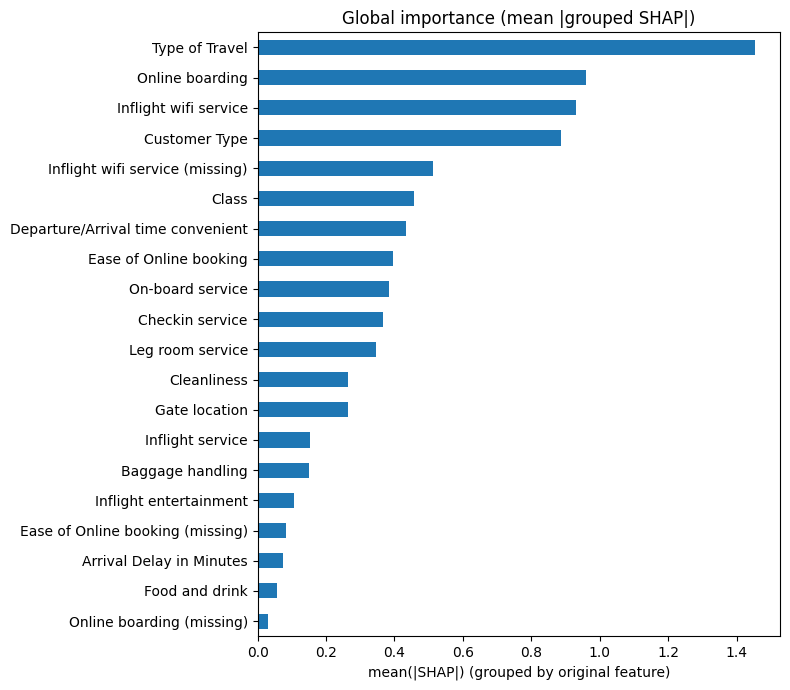

In [40]:
top = global_importance.head(20).sort_values()
plt.figure(figsize=(8, 7))
top.plot(kind="barh")
plt.title("Global importance (mean |grouped SHAP|)")
plt.xlabel("mean(|SHAP|) (grouped by original feature)")
plt.tight_layout()
plt.show()


In [42]:
# proba satisfied sur tout X_explain (ou tout X_test)
proba = best_model.predict_proba(X_explain)[:, 1]

# Cohorte: predicted dissatisfied
mask_diss = proba < 0.6

print("Cohorte dissatisfied n=", mask_diss.sum(), "/", len(mask_diss))


Cohorte dissatisfied n= 1150 / 2000


In [43]:
# dataframe shap (encodé)
shap_enc = pd.DataFrame(shap_values.values, columns=feature_names)

# group mapping (ta fonction origin_var)
group_map = pd.Series(feature_names, index=feature_names).apply(origin_var)

# groupé par variable d'origine
shap_grouped = shap_enc.groupby(group_map, axis=1).sum()

# cohorte
shap_grouped_diss = shap_grouped.loc[mask_diss]

cohort_mean_abs = shap_grouped_diss.abs().mean(axis=0).sort_values(ascending=False)
cohort_mean_signed = shap_grouped_diss.mean(axis=0).sort_values()

print("Top 15 (mean |SHAP|) - cohort dissatisfied")
display(cohort_mean_abs.head(15))

print("\nTop 10 qui poussent vers dissatisfaction (mean signed SHAP negative)")
display(cohort_mean_signed.head(10))

print("\nTop 10 qui poussent vers satisfaction (mean signed SHAP positive)")
display(cohort_mean_signed.tail(10).sort_values(ascending=False))


Top 15 (mean |SHAP|) - cohort dissatisfied


Type of Travel                       1.659717
Customer Type                        0.975042
Online boarding                      0.909176
Inflight wifi service                0.795876
Class                                0.433686
Departure/Arrival time convenient    0.423135
Checkin service                      0.395660
On-board service                     0.375623
Ease of Online booking               0.355615
Leg room service                     0.336316
Cleanliness                          0.291016
Inflight wifi service (missing)      0.277167
Gate location                        0.233207
Baggage handling                     0.154835
Inflight service                     0.154454
dtype: float64


Top 10 qui poussent vers dissatisfaction (mean signed SHAP negative)


Type of Travel                    -0.570403
Online boarding                   -0.446983
Inflight wifi service             -0.309786
Inflight wifi service (missing)   -0.277167
Class                             -0.209593
Checkin service                   -0.168947
Cleanliness                       -0.133117
Ease of Online booking            -0.117729
Customer Type                     -0.084615
On-board service                  -0.051376
dtype: float64


Top 10 qui poussent vers satisfaction (mean signed SHAP positive)


Gate location                       0.022445
Food and drink                      0.018212
Ease of Online booking (missing)    0.002622
Age                                 0.001326
Leg room service (missing)          0.001133
Gate location (missing)             0.000000
Seat comfort (missing)              0.000000
Cleanliness (missing)               0.000000
Checkin service (missing)           0.000000
Gender                             -0.000132
dtype: float64

In [44]:
mask_sat = proba >= 0.6

mean_abs_diss = shap_grouped.loc[mask_diss].abs().mean()
mean_abs_sat  = shap_grouped.loc[mask_sat].abs().mean()

delta = (mean_abs_diss - mean_abs_sat).sort_values(ascending=False)

print("Variables plus 'actives' chez les dissatisfied (delta mean|SHAP|)")
display(delta.head(15))

Variables plus 'actives' chez les dissatisfied (delta mean|SHAP|)


Type of Travel                      0.484621
Customer Type                       0.205873
Checkin service                     0.068996
Cleanliness                         0.060861
Inflight entertainment              0.011504
Arrival Delay in Minutes            0.009917
Baggage handling                    0.007798
Food and drink                      0.007613
Age                                 0.007053
Inflight service                    0.005905
Seat comfort                        0.004615
Inflight entertainment (missing)    0.002248
Food and drink (missing)            0.001507
Leg room service (missing)          0.001133
On-board service (missing)          0.000206
dtype: float64

In [47]:
mean_signed_diss = shap_grouped.loc[mask_diss].mean()
mean_signed_sat  = shap_grouped.loc[mask_sat].mean()

delta_signed = (mean_signed_diss - mean_signed_sat).sort_values()
display(delta_signed.head(15))   # plus négatif chez les dissatisfied
display(delta_signed.tail(15))   # plus positif chez les dissatisfied


Type of Travel                      -1.615404
Online boarding                     -1.288432
Inflight wifi service               -0.870877
Inflight wifi service (missing)     -0.586942
Class                               -0.517265
Customer Type                       -0.367631
On-board service                    -0.319536
Leg room service                    -0.269688
Checkin service                     -0.226644
Ease of Online booking              -0.225387
Cleanliness                         -0.208898
Baggage handling                    -0.108210
Inflight entertainment              -0.103495
Departure/Arrival time convenient   -0.102135
Inflight service                    -0.099694
dtype: float64

Departure/Arrival time convenient (missing)   -0.007071
Online boarding (missing)                     -0.006458
Inflight entertainment (missing)              -0.002248
Food and drink (missing)                      -0.001507
Inflight service (missing)                    -0.000206
On-board service (missing)                    -0.000206
Gender                                        -0.000175
Checkin service (missing)                      0.000000
Seat comfort (missing)                         0.000000
Cleanliness (missing)                          0.000000
Gate location (missing)                        0.000000
Leg room service (missing)                     0.001133
Age                                            0.006239
Food and drink                                 0.031705
Ease of Online booking (missing)               0.037384
dtype: float64